In [ ]:
"""
Author    : Mohammad Norizadeh Cherloo
Project   : MNIST Digit Classification
Algorithm : LeNet-5 – PyTorch
"""
import torch
from sklearn import  metrics
from matplotlib import pyplot as plt
from sklearn import preprocessing as prep
from torch.utils.data import TensorDataset,DataLoader,Dataset
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.datasets import load_digits
from torch.nn import functional as F
import torchvision
from torchvision.transforms import ToTensor, Lambda
from torch import nn, optim
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay

c:\onlinebme\course-online\Pytorch\PyTorch\.conda\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
c:\onlinebme\course-online\Pytorch\PyTorch\.conda\lib\site-packages\torchvision\io\image.py:13: UserWarning: Failed to load image Python extension: '[WinError 127] The specified procedure could not be found'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


In [2]:
from torch.utils.data import DataLoader, random_split

# %% MNIST dataset
num_classes = 10
batch_size = 32

full_train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    transform=ToTensor(),
    download=True
)

test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    transform=ToTensor(),
)


In [3]:
train_size = 50000
val_size   = 10000

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size]
)


In [4]:
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)


In [5]:
class LeNet_5(nn.Module):
    def __init__(self,
                 in_channels=1,
                 out_channels1=6,
                 kernel_size1=(5,5),
                 pool_size1=(2,2),
                 
                 out_channels2=16,
                 kernel_size2=(5,5),
                 pool_size2=(2,2),
                 
                 n_fc1=120,
                 n_fc2=84,
                 n_fc3= 10):
        super(LeNet_5, self).__init__()
        
        self.conv1= nn.Conv2d(in_channels=in_channels,
                              out_channels=out_channels1,
                              kernel_size=kernel_size1,
                              padding= (kernel_size1[0]//2, kernel_size1[1]//2),
                              groups=1)
        self.bn_c1= nn.BatchNorm2d(num_features=out_channels1,momentum=0.1)
        self.pool1= nn.MaxPool2d(kernel_size=pool_size1,
                                 stride=pool_size1)
        
        self.conv2= nn.Conv2d(in_channels=out_channels1,
                              out_channels=out_channels2,
                              kernel_size=kernel_size2,
                              padding= (kernel_size2[0]//2, kernel_size2[1]//2),
                               groups=1)
        
        self.bn_c2= nn.BatchNorm2d(num_features=out_channels2,momentum=0.1)
        
        self.pool2= nn.MaxPool2d(kernel_size=pool_size2,
                                 stride=pool_size2)
        cnn_dim=out_channels2* ((28//pool_size1[0]//pool_size2[0])*(28//pool_size1[1]//pool_size2[1]))
        self.fc1= nn.Linear(in_features=cnn_dim,
                            out_features=n_fc1)
        self.bn_f1= nn.BatchNorm1d(num_features=n_fc1,momentum=0.1)
        
        self.fc2= nn.Linear(in_features=n_fc1,
                            out_features=n_fc2)
        self.bn_f2= nn.BatchNorm1d(num_features=n_fc2,momentum=0.1)
        self.fc3= nn.Linear(in_features=n_fc2,
                            out_features=n_fc3)
        
        self.fun= nn.ReLU()
    
    def forward(self,X):
       # X: bs x 1 x H x W
       out= self.conv1(X)
       out= self.bn_c1(out)
       out= self.fun(out)
       out= self.pool1(out)
       
       out= self.conv2(out)
       out= self.bn_c2(out)
       out= self.fun(out)
       out= self.pool2(out)
       # flattening 
       flat= out.flatten(start_dim=1)
       out= self.fc1(flat)
       out= self.bn_f1(out)
       out= self.fun(out)
       
       out= self.fc2(out)
       out= self.bn_f2(out)
       out= self.fun(out)
       
       out= self.fc3(out)
       return out

In [6]:
model= LeNet_5(in_channels=1,
                out_channels1=6,
                kernel_size1=(5,5),
                pool_size1=(2,2),
                
                out_channels2=16,
                kernel_size2=(5,5),
                pool_size2=(2,2),
                
                n_fc1=120,
                n_fc2=84,
                n_fc3= 10)
n_out=10

criterion= nn.CrossEntropyLoss()
optimizer= optim.Adam(params=model.parameters(),
                      lr=0.001)

Loss(0:0): 2.328516 **** Valid Acc:10.200%
Loss(0:500): 0.292765 **** Valid Acc:97.270%
Loss(0:1000): 0.198151 **** Valid Acc:97.690%
Loss(0:1500): 0.159516 **** Valid Acc:98.110%
Loss(1:0): 0.006803 **** Valid Acc:97.740%
Loss(1:500): 0.060417 **** Valid Acc:97.890%
Loss(1:1000): 0.058020 **** Valid Acc:98.340%
Loss(1:1500): 0.057901 **** Valid Acc:98.240%


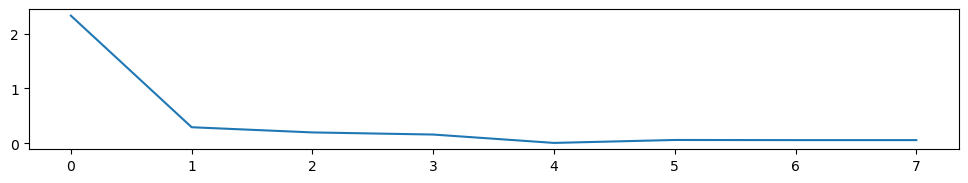

In [7]:
cost=[]
epoch=2
for iter in range(epoch):
     er=[]
     for i,(xbatch,ybatch) in enumerate(train_loader):
          model.train()
          # farward pass
          ypred= model(xbatch)
          optimizer.zero_grad()
          loss= criterion(ypred,ybatch.long())
          loss.backward()
          optimizer.step()

          er.append(loss.detach()) 
          if i%500==0:
               model.eval()
               loss= torch.mean(torch.tensor(er))
               cost.append(loss)
               # validation
               with torch.no_grad():
                    y_pred=[]
                    y_true=[]
                    for j,(xbatch,ybatch) in enumerate(val_loader):
                         # farward pass
                         ypred= model(xbatch)
                         ypred= torch.argmax(ypred,dim=1)
                         y_pred.extend(ypred.numpy())
                         y_true.extend(ybatch.numpy())
                         
                    y_pred= np.array(y_pred)
                    y_true= np.array(y_true)
                    accuracy= np.sum(y_true==y_pred)/y_pred.shape[0]*100
                    print(f'Loss({iter}:{i}): {loss:.6f} **** Valid Acc:{accuracy:.3f}%')
               model.train()
cost=torch.tensor(cost)
plt.figure(figsize=(12,4))
plt.subplot(2,1,1)
plt.plot(cost)
plt.show()

Total accuracy:98.860%
accuracy0:99.184%
accuracy1:99.648%
accuracy2:98.740%
accuracy3:99.406%
accuracy4:98.778%
accuracy5:98.318%
accuracy6:98.643%
accuracy7:98.930%
accuracy8:98.973%
accuracy9:97.820%


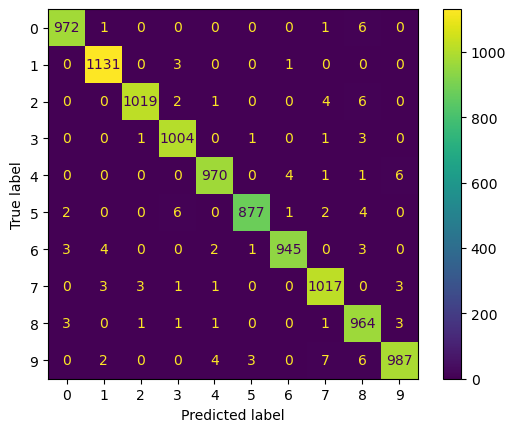

In [8]:
# validation
y_pred=[]
y_true=[]
model.eval()
with torch.no_grad():
    for i,(xbatch,ybatch) in enumerate(test_loader):
        # farward pass
        ypred= model(xbatch)
        ypred= torch.argmax(ypred,dim=1)
        y_pred.extend(ypred.numpy())
        y_true.extend(ybatch.numpy())
        
    y_pred= np.array(y_pred)
    y_true= np.array(y_true)

    
    #%% test trained Neural Network
    C= confusion_matrix(y_true,y_pred)
    # print(C)
    accuracy= np.sum(np.diag(C))/ np.sum(C) *100
    print(f'Total accuracy:{accuracy:.3f}%')

for i in range(n_out):
    accuracyi= C[i,i]/ np.sum(C[i,:]) *100
    print(f'accuracy{i}:{accuracyi:.3f}%')
# plt.figure()
disp= ConfusionMatrixDisplay(C)
disp.plot()
plt.show()